# Fashion-MNIST Image Classification: ANN vs CNN Performance Comparison

## Objective
The goal of this project is to compare the performance of an Artificial Neural Network (ANN) and a Convolutional Neural Network (CNN) on the Fashion-MNIST dataset.

## Goals
- Load and explore the Fashion-MNIST dataset
- Build an ANN model
- Build a CNN model
- Compare their accuracies
- Analyze model performance using confusion matrix and error analysis
- Understand why CNN performs better than ANN for image classification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Test Images Shape :", X_test.shape)
print("Test Labels Shape :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Test Images Shape : (10000, 28, 28)
Test Labels Shape : (10000,)


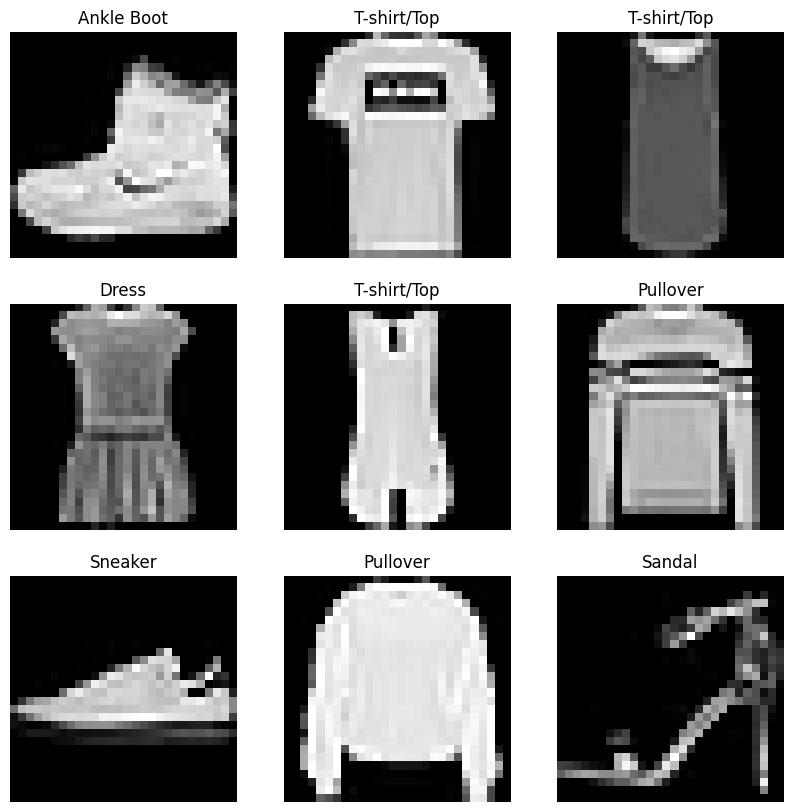

In [ ]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [ ]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [ ]:
print("Minimum Pixel Value:", X_train[0].min())
print("Maximum Pixel Value:", X_train[0].max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
print("Minimum Pixel Value:", X_train[0].min())
print("Maximum Pixel Value:", X_train[0].max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

ann_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

ann_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("ANN model compiled successfully!")

ANN model compiled successfully!


In [ ]:
history_ann = ann_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8176 - loss: 0.5197 - val_accuracy: 0.8510 - val_loss: 0.4199
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8602 - loss: 0.3922 - val_accuracy: 0.8653 - val_loss: 0.3733
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8730 - loss: 0.3471 - val_accuracy: 0.8619 - val_loss: 0.3801
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8835 - loss: 0.3216 - val_accuracy: 0.8790 - val_loss: 0.3421
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8895 - loss: 0.3016 - val_accuracy: 0.8798 - val_loss: 0.3298
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8954 - loss: 0.2864 - val_accuracy: 0.8734 - val_loss: 0.3650
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8983 - loss: 0.2756 - val_accuracy: 0.8875 - val_loss: 0.3138
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9044 - loss: 0.2613 - 

In [ ]:
test_loss_ann, test_acc_ann = ann_model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc_ann)
print("Test Loss:", test_loss_ann)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8802 - loss: 0.3498
Test Accuracy: 0.8802000284194946
Test Loss: 0.349811315536499


In [ ]:
print("Current Shape:", X_train.shape)

Current Shape: (60000, 28, 28)


In [ ]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [ ]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.8580 - loss: 0.4027 - val_accuracy: 0.8886 - val_loss: 0.3178
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9013 - loss: 0.2721 - val_accuracy: 0.9032 - val_loss: 0.2691
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9166 - loss: 0.2281 - val_accuracy: 0.9116 - val_loss: 0.2504
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9300 - loss: 0.1926 - val_accuracy: 0.9144 - val_loss: 0.2456
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9390 - loss: 0.1673 - val_accuracy: 0.9077 - val_loss: 0.2602
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9467 - loss: 0.1432 - val_accuracy: 0.9096 - val_loss: 0.2618
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9559 - loss: 0.1195 - val_accuracy: 0.9163 - val_loss: 0.2677
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9622 -

In [ ]:
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(
    X_test_cnn,
    y_test
)

print("CNN Test Accuracy:", test_acc_cnn)
print("CNN Test Loss:", test_loss_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9123 - loss: 0.3398
CNN Test Accuracy: 0.9122999906539917
CNN Test Loss: 0.33982038497924805


In [ ]:
print(history_ann.history.keys())
print(history_cnn.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


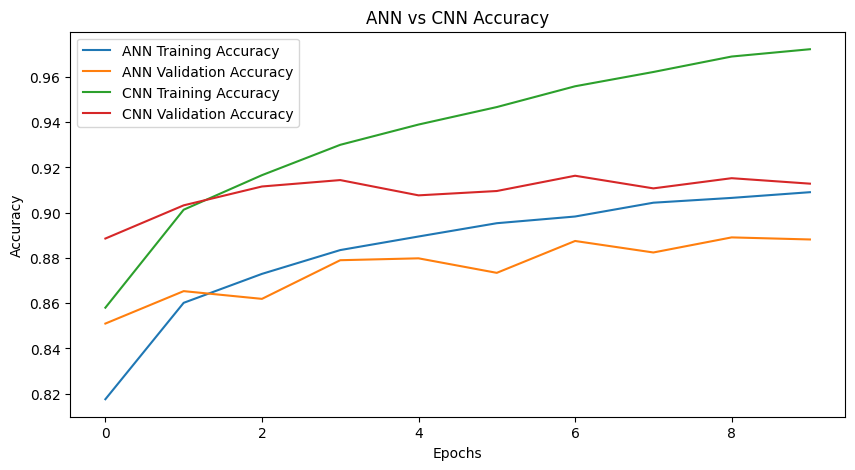

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_ann.history['accuracy'], label='ANN Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation Accuracy')

plt.plot(history_cnn.history['accuracy'], label='CNN Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')

plt.title('ANN vs CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

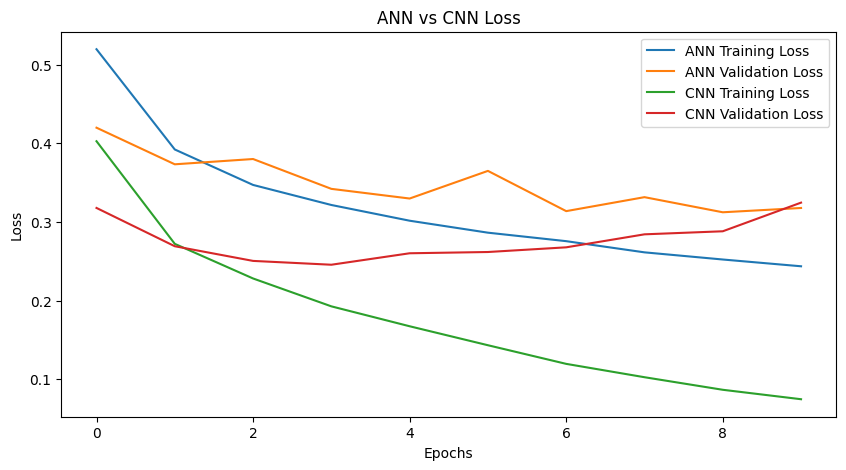

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_ann.history['loss'], label='ANN Training Loss')
plt.plot(history_ann.history['val_loss'], label='ANN Validation Loss')

plt.plot(history_cnn.history['loss'], label='CNN Training Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')

plt.title('ANN vs CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
import numpy as np

y_pred_probs = cnn_model.predict(X_test_cnn)

y_pred = np.argmax(y_pred_probs, axis=1)

print(y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[9 2 1 1 6 1 4 6 5 7]


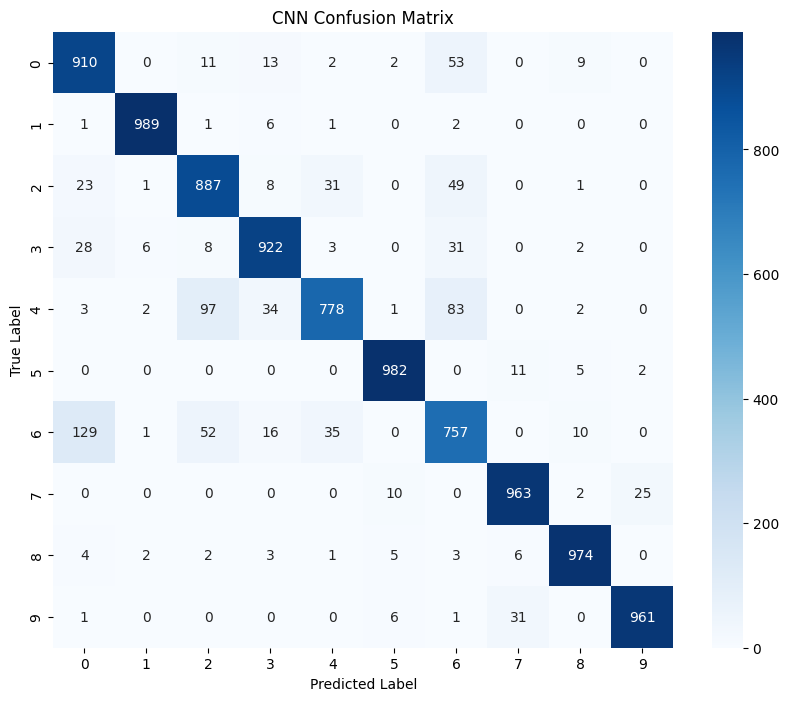

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
misclassified = np.where(y_pred != y_test)[0]

print("Number of Misclassified Images:", len(misclassified))

Number of Misclassified Images: 877


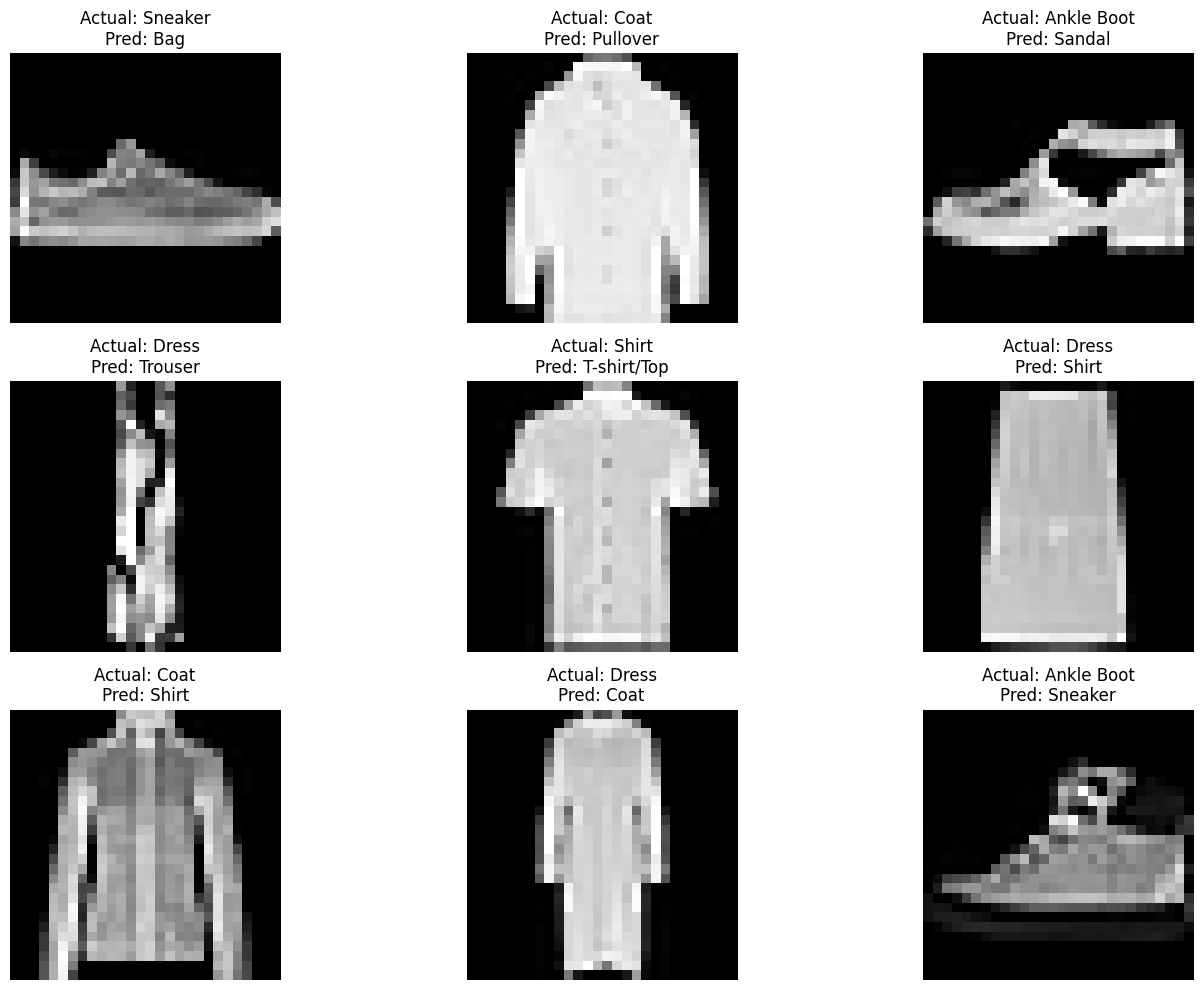

In [ ]:
plt.figure(figsize=(15,10))

for i in range(9):
    idx = misclassified[i]

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[idx], cmap='gray')

    plt.title(
        f"Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'ANN': [87.84, 0.3487],
    'CNN': [91.23, 0.3398]
})

comparison

,Metric,ANN,CNN
0,Test Accuracy,87.8400,91.2300
1,Test Loss,0.3487,0.3398


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving handbag.jpg to handbag.jpg


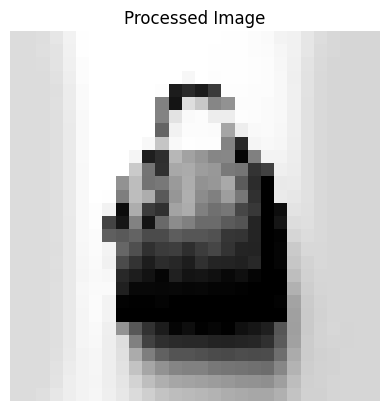

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img(
    'handbag.jpg',
    color_mode='grayscale',
    target_size=(28,28)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

plt.imshow(img_array.squeeze(), cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = cnn_model.predict(img_array)

predicted_class = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_class])

print("\nPrediction Probabilities:")
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Class: Sandal

Prediction Probabilities:
[[1.9506400e-02 9.6703530e-04 2.6694322e-03 4.5449569e-09 1.6896136e-04
  6.4804822e-01 3.2860130e-01 3.8306656e-11 3.8668353e-05 3.8611931e-09]]
